In [17]:
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [18]:
titanic = sns.load_dataset("titanic")

In [19]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [20]:
features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [21]:
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [22]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [24]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,2,Second,man,True,NaN,Southampton,no,True
887,1,1,0,19.0,0,0,30.0000,2,First,woman,False,B,Southampton,yes,True
888,0,3,0,28.0,1,2,23.4500,2,Third,woman,False,NaN,Southampton,no,False
889,1,1,1,26.0,0,0,30.0000,0,First,man,True,C,Cherbourg,yes,True


In [25]:
X = titanic[features]
y = titanic[target]

In [26]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 42
)

In [27]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
y_pred = model.predict(X_test)

In [29]:
print("accuracy : ",accuracy_score(y_test,y_pred))

accuracy :  0.7653631284916201


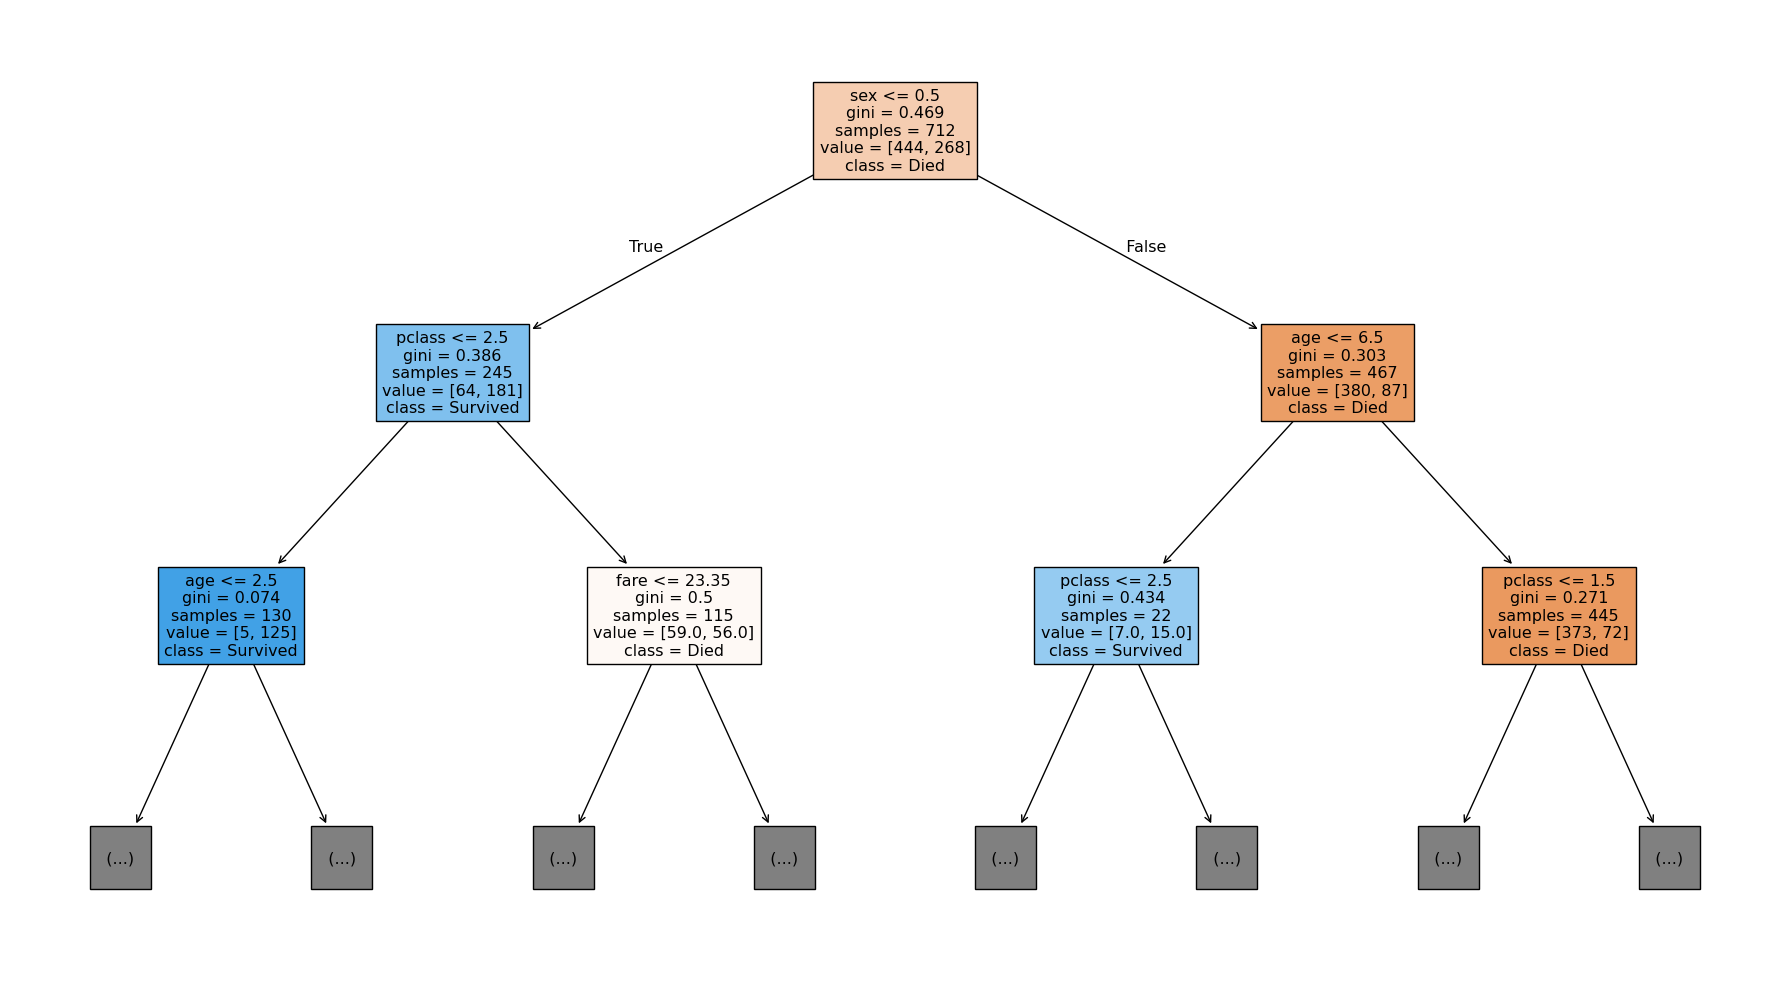

In [33]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
    max_depth=2
)

plt.tight_layout()
plt.show()

#Decision Tree with pre-pruning

for depth = 2, acc = 0.7653631284916201
for depth = 3, acc = 0.7988826815642458
for depth = 4, acc = 0.7988826815642458


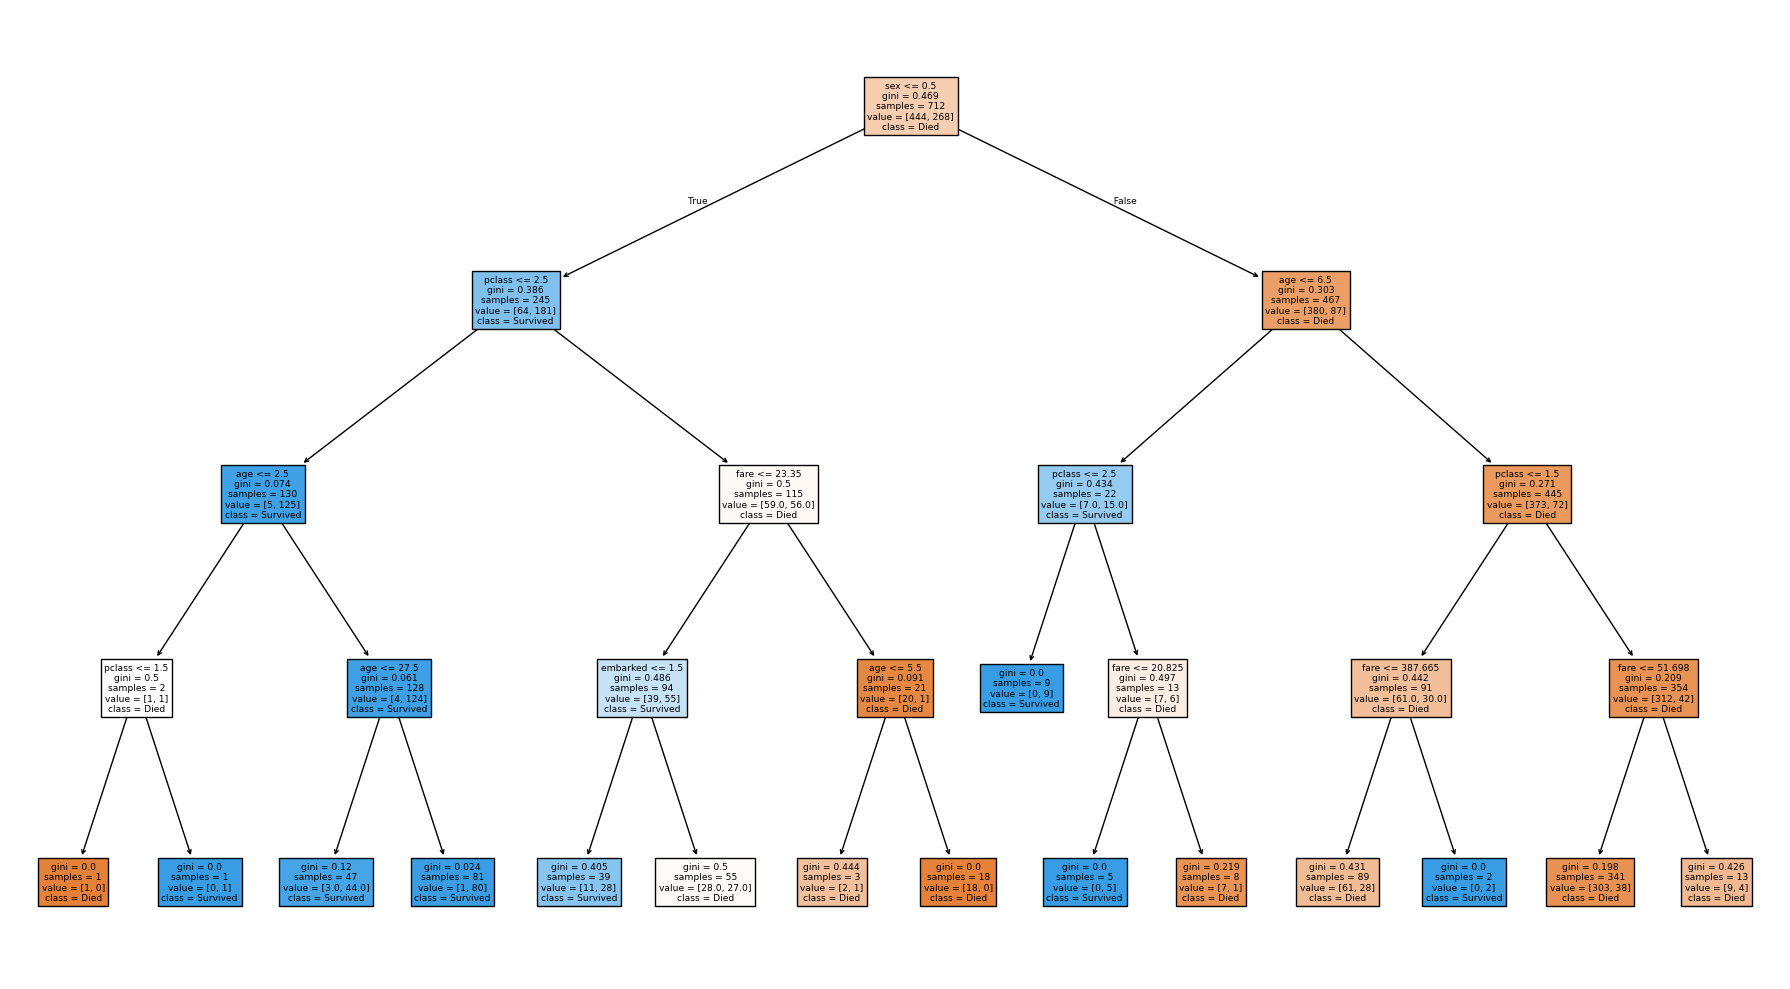

for depth = 5, acc = 0.7988826815642458
for depth = 6, acc = 0.7988826815642458
for depth = 7, acc = 0.7932960893854749
for depth = 8, acc = 0.7932960893854749
for depth = 9, acc = 0.7877094972067039
for depth = 10, acc = 0.776536312849162


In [41]:
max_depths = [2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train,y_train)
    acc = model.score(X_test,y_test)
    print(f"for depth = {depth}, acc = {acc}")

    if depth == 4:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died","Survived"],
            filled = True,
        )
        plt.tight_layout()
        plt.show()

for split = 10, acc = 0.8100558659217877


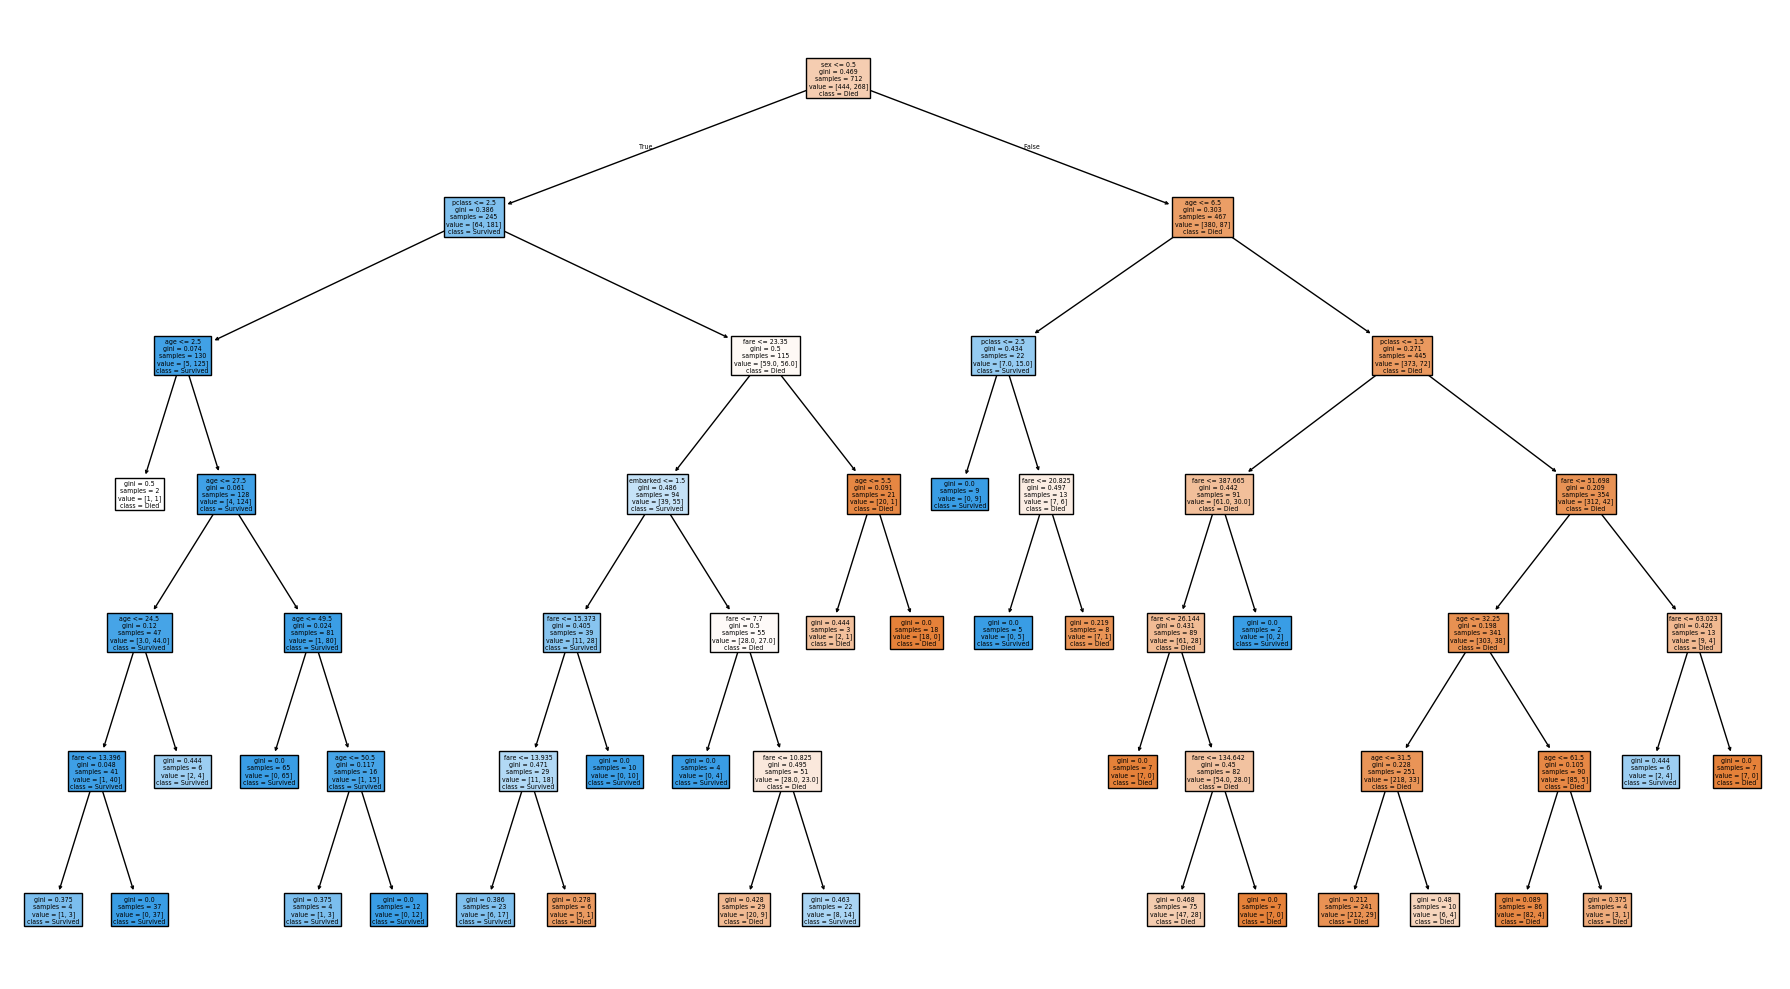

for split = 15, acc = 0.8044692737430168
for split = 20, acc = 0.8044692737430168
for split = 25, acc = 0.7988826815642458
for split = 30, acc = 0.7877094972067039
for split = 35, acc = 0.7877094972067039


In [42]:
min_samples_splits  = [10,15,20,25,30,35]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth = 6,min_samples_split = split)
    model.fit(X_train,y_train)
    acc = model.score(X_test,y_test)
    print(f"for split = {split}, acc = {acc}")

    if split == 10:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died","Survived"],
            filled = True,
        )
        plt.tight_layout()
        plt.show()

# Decision Tree with post-pruning

In [45]:
X = titanic[features]
y = titanic[target]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 42
)

full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [52]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [54]:
trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42,ccp_alpha=alpha)
    model.fit(X_train,y_train)

    trees.append((model,alpha))

In [56]:
best_acc = 0
best_alpha = 0
for model, alpha in trees:
    curr_acc = model.score(X_test,y_test)
    if curr_acc>best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [58]:
best_alpha

np.float64(0.0015407231242023183)

In [61]:
best_model = DecisionTreeClassifier(random_state = 42,ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


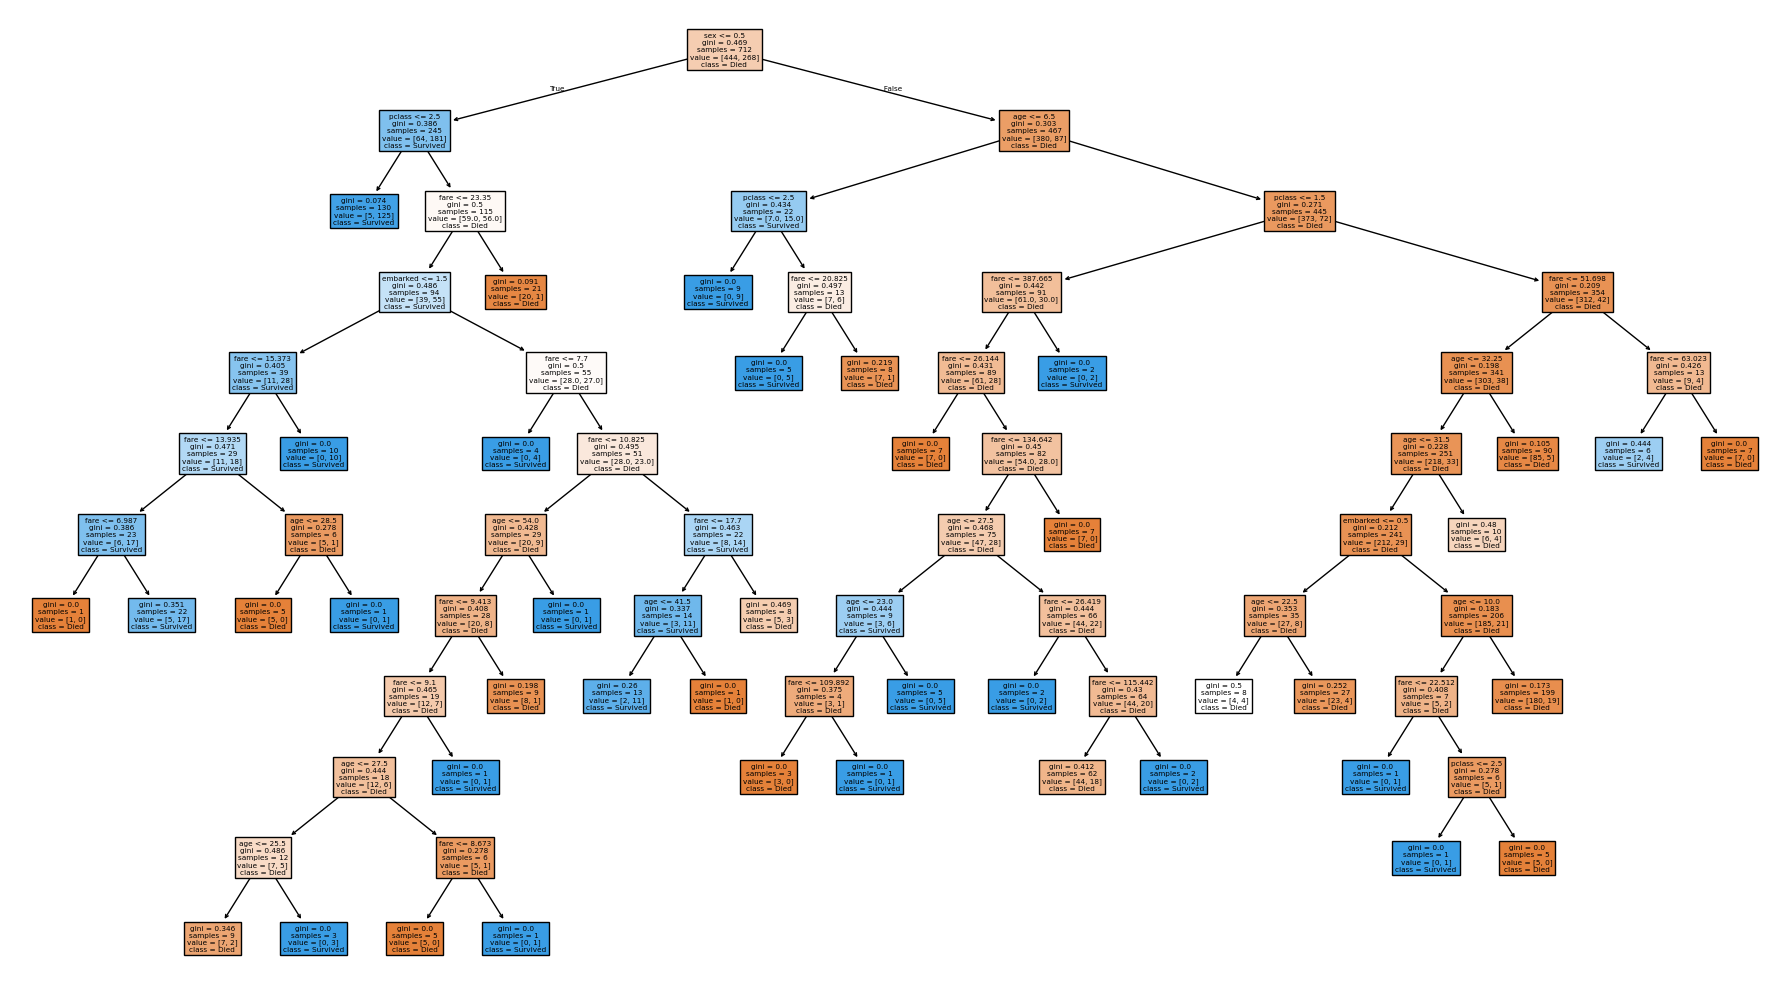

In [62]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
)
plt.tight_layout()
plt.show()

In [63]:
print(best_model.score(X_test,y_test))

0.8379888268156425
